In [2]:
import fastf1 as ff1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os #컴퓨터 폴더를 제어하는 라이브러리

#'f1_cache'라는 이름의 폴더가 없으면 자동으로 새로 만드는 코드
if not os.path.exists('f1_cache'):
    os.makedirs('f1_cache')

# 데이터 로딩 속도 향상을 위한 캐시 설정 (폴더명은 자유롭게 변경 가능) -> 
ff1.Cache.enable_cache('f1_cache') 

# 예시로 2024년 영국 그랑프리(Silverstone) 레이스 데이터 로드
# 실버스톤은 타이어 마모(Degradation)가 심하기로 유명한 서킷입니다.
session = ff1.get_session(2024, 'Great Britain', 'R')
session.load()

# 전체 랩 데이터 가져오기
laps = session.laps
print(laps[['Driver', 'LapNumber', 'LapTime', 'TyreLife', 'Compound']].head())

events      WARNING 	Correcting user input 'Great Britain' to 'Austrian Grand Prix'
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '81', '55', '44', '1', '27', '11', '20', '3', '10', '16', '31', '18', '22', '23', '77',

  Driver  LapNumber                LapTime  TyreLife Compound
0    RUS        1.0 0 days 00:01:14.401000       1.0   MEDIUM
1    RUS        2.0 0 days 00:01:10.580000       2.0   MEDIUM
2    RUS        3.0 0 days 00:01:10.441000       3.0   MEDIUM
3    RUS        4.0 0 days 00:01:10.467000       4.0   MEDIUM
4    RUS        5.0 0 days 00:01:10.193000       5.0   MEDIUM


🏎️ 2025 캐나다 그랑프리 레이스 데이터를 로드 중입니다...


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '1', '12', '81', '16', '44', '14', '27', '31', '55', '87', '22', '43', '5', '10', '6', '18', '4', '30', '23']
/var/folders/xs/6r719pn52v78jwn79r495lv00000gn/T/ipykernel_10


📊 드라이버별 타이어 스틴트 정보:

[RUS]
 - Stint 1.0: Compound=MEDIUM, Max Tyre Age=15.0 laps
 - Stint 2.0: Compound=HARD, Max Tyre Age=29.0 laps
 - Stint 3.0: Compound=HARD, Max Tyre Age=24.0 laps

[VER]
 - Stint 1.0: Compound=MEDIUM, Max Tyre Age=14.0 laps
 - Stint 2.0: Compound=HARD, Max Tyre Age=24.0 laps
 - Stint 3.0: Compound=HARD, Max Tyre Age=29.0 laps


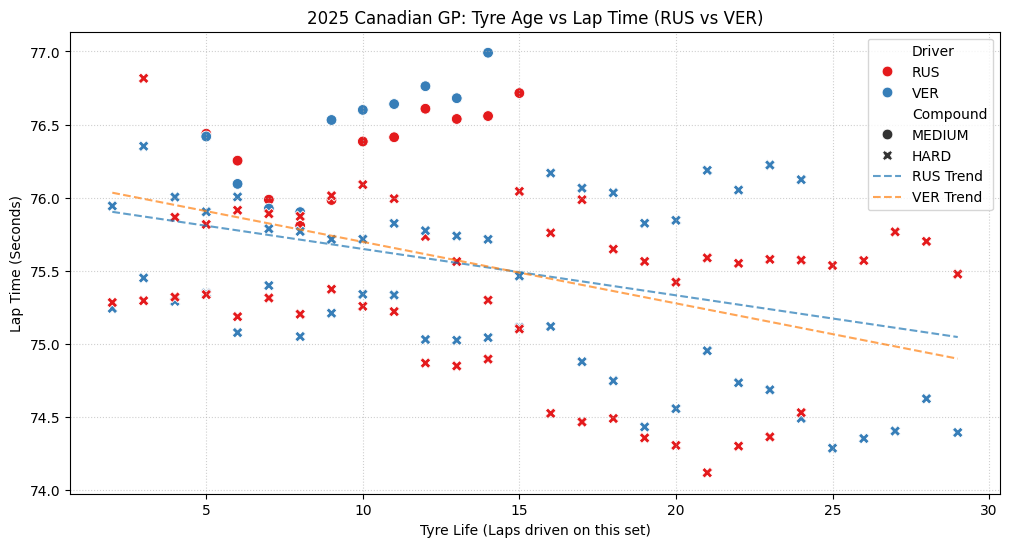


🤖 머신러닝 모델에 인풋으로 들어갈 핵심 컬럼들:
   Driver  LapNumber  TyreLife Compound  FuelProgression  TrackTemp  \
18    RUS        2.0       5.0   MEDIUM         0.028571       50.1   
19    VER        2.0       5.0   MEDIUM         0.028571       50.1   
38    RUS        3.0       6.0   MEDIUM         0.042857       50.2   
39    VER        3.0       6.0   MEDIUM         0.042857       50.2   
58    RUS        4.0       7.0   MEDIUM         0.057143       50.3   

    LapTimeSec  
18      76.437  
19      76.418  
38      76.253  
39      76.094  
58      75.986  


In [3]:
import fastf1 as ff1
import pandas as pd #데이터 분석
import numpy as np #수치 계산
import matplotlib.pyplot as plt #데이터 시각화
import seaborn as sns #고급 시각화

# 1. FastF1 캐시 설정 및 데이터 로드
ff1.Cache.enable_cache('f1_cache')

print("🏎️ 2025 캐나다 그랑프리 레이스 데이터를 로드 중입니다...")
session = ff1.get_session(2025, 'Canada', 'R')
session.load()

# 2. 전체 랩 데이터 추출 및 기본 정제
laps = session.laps

# 세이프티 카(SC), 버추얼 세이프티 카(VSC), 피트스톱 랩 등 
# 타이어 마모와 상관없이 랩타임이 튀는 '아웃라이어'를 제거하기 위한 필터링
# 보통 정상 랩타임의 107% 이내이거나 PitOut/PitIn이 없는 랩을 클린 랩으로 봅니다.
clean_laps = laps.pick_wo_box()
clean_laps = clean_laps[clean_laps['LapTime'].notna()]

# LapTime을 초(seconds) 단위로 변환
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

# 3. [피처 엔지니어링 1] 연료 소모 변수 만들기
# 레이스가 진행될수록(LapNumber가 커질수록) 차가 가벼워지는 효과를 반영합니다.
# 캐나다 GP 전체 랩 수(보통 70랩) 대비 현재 몇 번째 랩인지를 비율로 계산합니다.
max_laps = laps['LapNumber'].max()
clean_laps['FuelProgression'] = clean_laps['LapNumber'] / max_laps

# 4. [피처 엔지니어링 2] 날씨(트랙 온도) 데이터 병합하기
# 경기 중 실시간으로 변한 날씨 장부를 가져옵니다.
weather_data = session.weather_data[['Time', 'TrackTemp']]

# 랩이 기록된 시간과 날씨가 기록된 시간을 기준으로 판다스가 알아서 가장 가까운 시간의 온도를 매칭해줍니다.
clean_laps = pd.merge_asof(
    clean_laps.sort_values('Time'), 
    weather_data.sort_values('Time'), 
    on='Time', 
    direction='nearest'
)

# 3. 조지 러셀(RUS)과 주요 경쟁 드라이버 데이터 필터링
# 비교를 위해 당시 상위권이었던 VER(페르스타펜)이나 LEC(르클레르)를 함께 추출합니다.
target_drivers = ['RUS', 'VER'] 
df_analysis = clean_laps[clean_laps['Driver'].isin(target_drivers)].copy()

# [노이즈 제거] 78초 이상 걸린 VSC/돌발상황 랩 싹둑 잘라내기
df_analysis = df_analysis[df_analysis['LapTimeSec'] < 78.0]

# 4. 간단한 스틴트(Stint) 정보 확인
print("\n📊 드라이버별 타이어 스틴트 정보:")
for driver in target_drivers:
    driver_laps = df_analysis[df_analysis['Driver'] == driver]
    stints = driver_laps['Stint'].unique()
    print(f"\n[{driver}]")
    for stint in stints:
        stint_data = driver_laps[driver_laps['Stint'] == stint]
        compound = stint_data['Compound'].iloc[0]
        max_age = stint_data['TyreLife'].max()
        print(f" - Stint {stint}: Compound={compound}, Max Tyre Age={max_age} laps")

# 5. 타이어 마모도(Degradation) 시각화
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_analysis, 
    x='TyreLife', 
    y='LapTimeSec', 
    hue='Driver', 
    style='Compound',
    palette='Set1',
    s=60
)

# 마모 추세를 보기 위한 회귀선 추가 (간단한 선형 추세)
for driver in target_drivers:
    driver_data = df_analysis[df_analysis['Driver'] == driver]
    if not driver_data.empty:
        z = np.polyfit(driver_data['TyreLife'], driver_data['LapTimeSec'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(driver_data['TyreLife'].min(), driver_data['TyreLife'].max(), 100)
        plt.plot(x_range, p(x_range), linestyle='--', alpha=0.7, label=f'{driver} Trend')

plt.title('2025 Canadian GP: Tyre Age vs Lap Time (RUS vs VER)')
plt.xlabel('Tyre Life (Laps driven on this set)')
plt.ylabel('Lap Time (Seconds)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 머신러닝에 들어갈 최종 데이터 형태 슬쩍 확인해보기
print("\n🤖 머신러닝 모델에 인풋으로 들어갈 핵심 컬럼들:")
print(df_analysis[['Driver', 'LapNumber', 'TyreLife', 'Compound', 'FuelProgression', 'TrackTemp', 'LapTimeSec']].head())

In [4]:
# 머신러닝을 위한 사이킷런 도구 상자 가져오기
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. 문제집(X)과 정답지(y) 나누기
# ==========================================
# 모델이 학습할 힌트 (독립변수 X)
features = ['TyreLife', 'FuelProgression', 'TrackTemp']
X = df_analysis[features]

# 모델이 맞추어야 할 최종 정답 (종속변수 y): 초 단위 랩타임
y = df_analysis['LapTimeSec']

# ==========================================
# 2. 훈련용 데이터와 시험용 데이터 분리하기 (Train / Test Split)
# ==========================================
# 전체 데이터의 80%는 교과서(Train)로 쓰고, 20%는 모의고사(Test) 시험지로 숨겨둡니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📚 교과서 문제 수: {len(X_train)}개 | 📝 모의고사 문제 수: {len(X_test)}개")

# ==========================================
# 3. 인공지능 모델 생성 및 학습 (Training)
# ==========================================
# 선형 회귀라는 수학적 AI 모델을 뇌가 비어있는 상태로 생성합니다.
model = LinearRegression()

# .fit() 함수를 쓰면 컴퓨터가 코피를 흘리며 교과서와 정답지를 맞춰보며 공부를 시작합니다.
model.fit(X_train, y_train)
print("🤖 AI 모델이 F1 레이스 데이터를 완벽하게 학습했습니다!")

# ==========================================
# 4. 모의고사 치르기 및 채점 (Evaluation)
# ==========================================
# 공부를 끝낸 AI에게 정답을 가린 모의고사(X_test)를 던져주고 정답을 맞춰보라고 합니다.
y_pred = model.predict(X_test)

# 채점하기 (수학적 평가지표 계산)
# MSE: 에러들의 제곱 평균 (0에 가까울수록 백점만점)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # 루트를 씌워 실제 '초' 단위와 단위를 맞춰줍니다.

# R2 Score: 이 데이터의 경향을 인공지능이 얼마나 잘 설명하는가? (1.0이면 100점 만점)
r2 = r2_score(y_test, y_pred)

print("\n🎯 --- AI 모델 최종 성적표 ---")
print(f"🔹 평균 오차(RMSE): {rmse:.3f} 초 (AI가 랩타임을 예측할 때 평균적으로 이 정도 틀림)")
print(f"🔹 모델 설명력(R² Score): {r2 * 100:.1f}% (전체 랩타임 변화의 이만큼을 AI가 완벽히 이해함)")

# ==========================================
# 5. AI가 알아낸 비밀 가중치(Coefficient) 확인하기
# ==========================================
print("\n🔍 AI가 수식을 풀며 발견한 F1 데이터의 비밀 지표:")
for feature, coef in zip(features, model.coef_):
    print(f"   • {feature}의 영향력: {coef:+.4f}")

📚 교과서 문제 수: 97개 | 📝 모의고사 문제 수: 25개
🤖 AI 모델이 F1 레이스 데이터를 완벽하게 학습했습니다!

🎯 --- AI 모델 최종 성적표 ---
🔹 평균 오차(RMSE): 0.251 초 (AI가 랩타임을 예측할 때 평균적으로 이 정도 틀림)
🔹 모델 설명력(R² Score): 82.6% (전체 랩타임 변화의 이만큼을 AI가 완벽히 이해함)

🔍 AI가 수식을 풀며 발견한 F1 데이터의 비밀 지표:
   • TyreLife의 영향력: +0.0087
   • FuelProgression의 영향력: -2.3418
   • TrackTemp의 영향력: +0.1244
